# F1 Fastest-Lap Speed — Regression Project

**Dataset:** `f1.csv` — Formula 1 race results merged with race, circuit, driver and
constructor information, covering the **1950–2024** seasons (26,759 race entries, 50
columns).

**Target variable:** `fastestLapSpeed` — the average speed (km/h) a driver achieved on
their fastest lap of the race.

**Why this target instead of finishing position?** An earlier version of this project used
final finishing position (`positionOrder`) as the target. On reflection, that target turned
out to be a weak choice for a regression showcase: within the modern era, grid position
alone correlates with it at **r ≈ 0.58**, and most of the remaining variance is driven by
race chaos (incidents, retirements, strategy) that simply isn't present as columns in this
data — capping any model's ceiling and making the exercise feel like "one feature does
all the work." Fastest-lap speed is a better regression target: it is a genuinely continuous
physical performance measurement, shaped by *several* things we can actually observe in the
data — the circuit's layout, altitude (air density affects engine power), the era's
aerodynamic/engine regulations, and how competitive a car/driver currently is — none of
which dominates the way grid position did before.

**The catch — and the point of this notebook:** this statistic is **~69% missing** overall.
As we'll show, that missingness isn't random — it reflects *how* the data was collected, and
handling it properly (rather than dropping most of the dataset or blindly filling with the
mean) is a core part of this project.

**Notebook structure:**
1. Data loading & initial exploration
2. Investigating the target variable and its missingness
3. Data cleaning & scoping
4. Missing-data imputation (validated experimentally)
5. Feature engineering
6. Feature selection & multicollinearity check
7. Preparing the data for modeling (encoding, scaling, train/test split)
8. Model training & comparison
9. Feature importance
10. Predicted vs. actual analysis
11. Conclusion & insights


In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# Preprocessing, imputation & modeling
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42


## 1. Data Loading & Initial Exploration

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/FOne/data/f1.csv', low_memory=False)
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (26759, 50)


,resultId,raceId,driverId,constructorId,circuitId,season,round,race_name,date,race_start_time,circuit_name,location,circuit_country,lat,lng,alt,circuitRef,driver_name,driver_number,code,nationality_driver,dob,driverRef,constructor_name,nationality_constructor,constructorRef,grid,position,positionText,positionOrder,points,laps,driver_race_time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,result_driver_number,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,18,1,1,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,albert_park,Lewis Hamilton,44,HAM,British,1985-01-07,hamilton,McLaren,British,mclaren,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,22,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,18,2,2,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,albert_park,Nick Heidfeld,\N,HEI,German,1977-05-10,heidfeld,BMW Sauber,German,bmw_sauber,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,3,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,18,3,3,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,albert_park,Nico Rosberg,6,ROS,German,1985-06-27,rosberg,Williams,British,williams,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,7,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,18,4,4,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,albert_park,Fernando Alonso,14,ALO,Spanish,1981-07-29,alonso,Renault,French,renault,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,5,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,18,5,1,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,albert_park,Heikki Kovalainen,\N,KOV,Finnish,1981-10-19,kovalainen,McLaren,British,mclaren,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,23,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [ ]:
# The source data uses the literal string '\\N' for missing values (a SQL-export artifact).
# Replace it with a proper NaN so pandas' missing-value tooling works correctly.
df = df_raw.replace('\\N', np.nan).copy()

# Correct dtypes for the columns we'll rely on
df['date'] = pd.to_datetime(df['date'])
df['dob'] = pd.to_datetime(df['dob'])
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')
df['laps'] = pd.to_numeric(df['laps'], errors='coerce')
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   resultId                 26759 non-null  int64         
 1   raceId                   26759 non-null  int64         
 2   driverId                 26759 non-null  int64         
 3   constructorId            26759 non-null  int64         
 4   circuitId                26759 non-null  int64         
 5   season                   26759 non-null  int64         
 6   round                    26759 non-null  int64         
 7   race_name                26759 non-null  str           
 8   date                     26759 non-null  datetime64[us]
 9   race_start_time          8290 non-null   str           
 10  circuit_name             26759 non-null  str           
 11  location                 26759 non-null  str           
 12  circuit_country          26759 non-null  st

## 2. Investigating the Target Variable and Its Missingness

Before doing anything else with `fastestLapSpeed`, we need to understand *why* so much of
it is missing. Blindly imputing 69% of a target column would be reckless — so we look at
the pattern first.


Overall missing: 69.2%


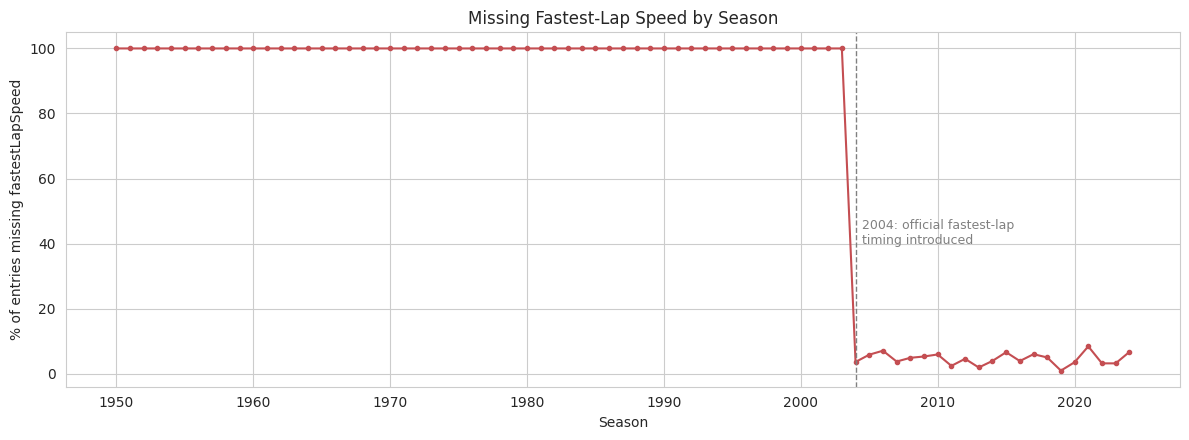

In [ ]:
print(f"Overall missing: {df['fastestLapSpeed'].isna().mean()*100:.1f}%")

missing_by_season = df.groupby('season')['fastestLapSpeed'].apply(lambda x: x.isna().mean()*100)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(missing_by_season.index, missing_by_season.values, marker='o', markersize=3, color='#C44E52')
ax.axvline(2004, color='gray', linestyle='--', linewidth=1)
ax.text(2004.5, 40, '2004: official fastest-lap\ntiming introduced', fontsize=9, color='gray')
ax.set_xlabel('Season')
ax.set_ylabel('% of entries missing fastestLapSpeed')
ax.set_title('Missing Fastest-Lap Speed by Season')
plt.tight_layout()
plt.show()


This is a striking, clean pattern: **every single race before 2004 is 100% missing**,
and from 2004 onward the missing rate drops to single digits. This isn't random noise — it's
a **data collection cutoff**. Official, sensor-based fastest-lap timing became a standard
part of F1 timekeeping starting in the 2004 season; before that, this specific statistic
simply was not part of the official record, even though every race obviously had a fastest
lap in reality.

This distinction matters a lot for how we handle the missing values:
- **Pre-2004 (systemic, 100% missing):** the value existed physically but was never
  recorded. Reconstructing it would mean extrapolating a model trained only on 2004+
  aerodynamics/engine data backward across 54 years of *fundamentally different* car
  generations (naturally-aspirated V8/V10/V12s, radically different tire and aero rules).
  That's more guesswork than imputation, so we won't attempt to backfill this era.
- **Post-2004 (sparse, a few % missing):** let's check whether *this* remaining gap looks
  recoverable.


In [ ]:
modern = df[df['season'] >= 2004].copy()
missing_modern = modern[modern['fastestLapSpeed'].isna()]
present_modern = modern[modern['fastestLapSpeed'].notna()]

print(f"2004+ missing rate: {modern['fastestLapSpeed'].isna().mean()*100:.1f}%")
print()
print('Laps completed -- rows MISSING fastestLapSpeed:')
print(missing_modern['laps'].describe())
print()
print('Laps completed -- rows WITH fastestLapSpeed:')
print(present_modern['laps'].describe())


2004+ missing rate: 4.6%

Laps completed -- rows MISSING fastestLapSpeed:
count    398.000000
mean       4.198492
std       16.375730
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       78.000000
Name: laps, dtype: float64

Laps completed -- rows WITH fastestLapSpeed:
count    8252.000000
mean       55.144086
std        15.015387
min         0.000000
25%        52.000000
50%        56.000000
75%        66.000000
max        87.000000
Name: laps, dtype: float64


Within the 2004+ era, the remaining missing rows have a **median of 0 laps completed**
(vs. 56 for rows with a recorded speed) — these are drivers who retired almost immediately
(crash, mechanical failure at the start) and genuinely never completed a full timed lap.
For these rows the statistic doesn't just go unrecorded, it **doesn't exist** — there is no
"fastest lap" to speak of. Imputing a number here would mean inventing an event that never
happened, so these rows should be **excluded**, not imputed.


## 3. Data Cleaning & Scoping

Based on the investigation above, we make two deliberate scoping decisions:

1. **Drop rows with `laps < 5`.** A driver needs to complete a handful of laps for a
   "fastest lap" to be a meaningful concept at all — below that, the value is not applicable,
   not just missing.
2. **Restrict to `season >= 2004`.** This is the era with reliable official timing for our
   target. It still leaves a large, modern, and analytically coherent dataset — and avoids
   the scientifically shaky move of projecting current-car aerodynamics backward onto 1950s
   machinery.

We also drop the same categories of leakage/near-empty/redundant columns identified in
earlier exploration (post-race outcome columns, mostly-empty practice/qualifying session
columns, and redundant identifier columns), and sort the data chronologically — essential
for the shifted rolling features we build in Section 5.


In [ ]:
df = df.sort_values(['date', 'driverId']).reset_index(drop=True)

# 1. A fastest lap requires having actually completed some laps
df = df[df['laps'] >= 5].reset_index(drop=True)

# 2. Scope to the era with reliable official timing for our target
df = df[df['season'] >= 2004].reset_index(drop=True)

# Drop leakage / near-empty / redundant columns (same reasoning as standard race-result EDA:
# these either reveal the race outcome itself, are >90% empty, or duplicate other columns)
leakage_cols = ['position', 'positionText', 'points', 'driver_race_time', 'milliseconds',
                 'fastestLap', 'rank', 'fastestLapTime', 'statusId', 'result_driver_number']
sparse_session_cols = ['race_start_time', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time',
                        'fp3_date', 'fp3_time', 'quali_date', 'quali_time',
                        'sprint_date', 'sprint_time']
redundant_id_cols = ['driverRef', 'constructorRef', 'circuitRef', 'race_name', 'location',
                      'driver_number', 'code', 'resultId', 'raceId', 'nationality_constructor']

df = df.drop(columns=leakage_cols + sparse_session_cols + redundant_id_cols)

print('Shape after scoping and cleaning:', df.shape)
print(f"Remaining missing fastestLapSpeed: {df['fastestLapSpeed'].isna().sum()} "
      f"({df['fastestLapSpeed'].isna().mean()*100:.1f}%)")


Shape after scoping and cleaning: (8214, 19)
Remaining missing fastestLapSpeed: 23 (0.3%)


## 4. Missing-Data Imputation (Validated Experimentally)

Only **23 rows** (~0.3%) now have a missing target — genuinely small gaps within the
reliable-timing era (edge cases in the source data, not systemic like the pre-2004 gap).
Rather than guessing which imputation method to trust, we **simulate the real missingness
pattern on data where we already know the true answer**, and measure how well different
standard techniques recover it. This tells us which method to trust *before* applying it to
the real gaps.

**Experiment design:** take the ~8,200 rows with a known `fastestLapSpeed`, randomly hide
20% of them (pretending we don't know the value), impute them back with each method, and
compare the imputed values against the real ones we hid.


In [ ]:
np.random.seed(RANDOM_STATE)

known = df[df['fastestLapSpeed'].notna()].reset_index(drop=True)
mask = np.random.rand(len(known)) < 0.20

sim = known.copy()
true_vals = sim.loc[mask, 'fastestLapSpeed'].copy()
sim.loc[mask, 'fastestLapSpeed'] = np.nan

impute_features = ['season', 'round', 'grid', 'lat', 'lng', 'alt']
print(f'Simulated missing: {mask.sum()} of {len(known)} rows ({mask.mean()*100:.0f}%)')


Simulated missing: 1689 of 8191 rows (21%)


In [ ]:
# Method 1: naive global mean -- the simplest possible baseline
pred_mean = sim['fastestLapSpeed'].fillna(sim['fastestLapSpeed'].mean())

# Method 2: group median by circuit -- accounts for track character
grp_median = sim.groupby('circuitId')['fastestLapSpeed'].transform('median')
pred_group = sim['fastestLapSpeed'].fillna(grp_median).fillna(sim['fastestLapSpeed'].mean())

# Method 3: KNN imputation -- fills each gap using the average of the k most
# similar rows (by season/round/grid/circuit location), a standard sklearn technique
knn_input = sim[impute_features + ['fastestLapSpeed']].copy()
knn_input[impute_features] = knn_input[impute_features].fillna(knn_input[impute_features].median())
pred_knn = pd.Series(
    KNNImputer(n_neighbors=7).fit_transform(knn_input)[:, -1],
    index=sim.index
)

# Method 4: model-based (regression) imputation -- train a Random Forest on the rows
# with a known value, then predict the hidden ones ("simulating" a plausible real value)
train_part = sim[sim['fastestLapSpeed'].notna()]
missing_part = sim[sim['fastestLapSpeed'].isna()]
rf_imputer = RandomForestRegressor(n_estimators=300, max_depth=12,
                                    random_state=RANDOM_STATE, n_jobs=-1)
rf_imputer.fit(train_part[impute_features], train_part['fastestLapSpeed'])
pred_rf = sim['fastestLapSpeed'].copy()
pred_rf.loc[missing_part.index] = rf_imputer.predict(missing_part[impute_features])

imputation_methods = {
    'Global Mean': pred_mean,
    'Circuit Median (grouped)': pred_group,
    'KNN Imputer (k=7)': pred_knn,
    'Random Forest (model-based)': pred_rf,
}


In [ ]:
impute_results = []
for name, preds in imputation_methods.items():
    recovered = preds.loc[mask]
    mae = mean_absolute_error(true_vals, recovered)
    rmse = np.sqrt(mean_squared_error(true_vals, recovered))
    r2 = r2_score(true_vals, recovered)
    impute_results.append({'Method': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

impute_results_df = pd.DataFrame(impute_results).sort_values('RMSE').reset_index(drop=True)
impute_results_df


,Method,MAE,RMSE,R2
0,Random Forest (model-based),2.543557,4.910828,0.947141
1,KNN Imputer (k=7),3.601021,6.059805,0.919513
2,Circuit Median (grouped),5.917163,8.658184,0.835691
3,Global Mean,16.227988,21.365675,-0.000554


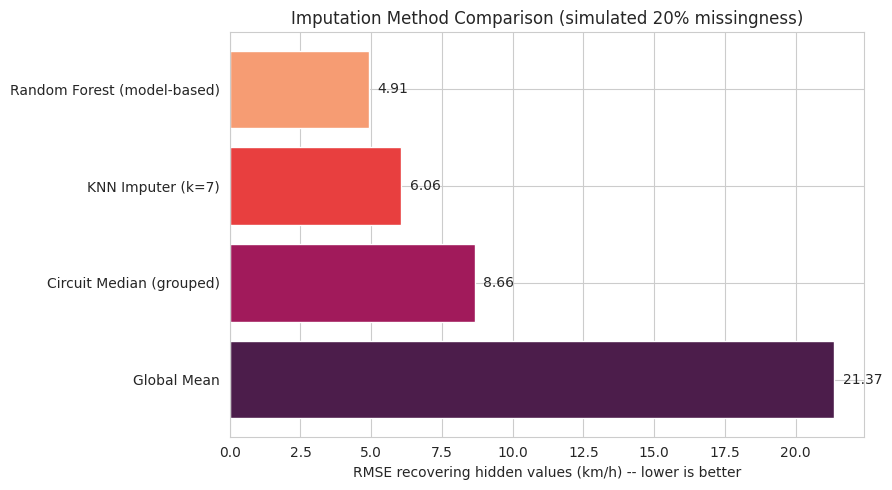

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = impute_results_df.sort_values('RMSE', ascending=False)
bars = ax.barh(order['Method'], order['RMSE'], color=sns.color_palette('rocket', len(order)))
ax.set_xlabel('RMSE recovering hidden values (km/h) -- lower is better')
ax.set_title('Imputation Method Comparison (simulated 20% missingness)')
for bar, val in zip(bars, order['RMSE']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')
plt.tight_layout()
plt.show()


The naive global mean is essentially useless here (R² ≈ 0 — no better than always
guessing the average), because fastest-lap speed varies enormously by circuit (a Monaco
street circuit vs. Monza's long straights are worlds apart). Grouping by circuit already
recovers most of the signal (R² ≈ 0.84). **Model-based imputation with a Random Forest
performs best** (R² ≈ 0.95, lowest MAE/RMSE) — it can combine circuit location, altitude,
season and grid together, capturing patterns the simpler methods miss. We'll use this
validated method to fill the real 23 missing values.


In [ ]:
best_method_name = impute_results_df.iloc[0]['Method']
print(f'Best-performing method: {best_method_name}')

# Apply Random Forest imputation to the REAL missing values in the full (unmasked) dataset
train_real = df[df['fastestLapSpeed'].notna()]
missing_real = df[df['fastestLapSpeed'].isna()]

final_imputer = RandomForestRegressor(n_estimators=300, max_depth=12,
                                       random_state=RANDOM_STATE, n_jobs=-1)
final_imputer.fit(train_real[impute_features], train_real['fastestLapSpeed'])
df.loc[df['fastestLapSpeed'].isna(), 'fastestLapSpeed'] = (
    final_imputer.predict(missing_real[impute_features])
)

print(f"Missing fastestLapSpeed remaining: {df['fastestLapSpeed'].isna().sum()}")


Best-performing method: Random Forest (model-based)


Missing fastestLapSpeed remaining: 0


## 5. Feature Engineering

With a complete target, we engineer features that describe circuit character, car/driver
competitiveness, and career context — all computed using **only past information**
relative to each race (rolling windows are shifted by one, so a race never sees its own
result baked into its own features):

- **`driver_age`** — the driver's age (years) on race day.
- **`driver_experience`** — races started prior to this one (career length so far).
- **`driver_form`** — the driver's mean fastest-lap speed over their previous 5 races.
- **`constructor_form`** — the same idea for the constructor (team) over their previous 10
  results, capturing current car competitiveness.
- **`circuit_avg_speed`** — the historical average fastest-lap speed recorded at this
  circuit *before* this race (an expanding, shifted mean) — a proxy for how fast a track
  characteristically is (e.g. Monza vs. Monaco).


In [ ]:
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25
df['driver_experience'] = df.groupby('driverId').cumcount()

df['driver_form'] = (
    df.groupby('driverId')['fastestLapSpeed']
      .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['constructor_form'] = (
    df.groupby('constructorId')['fastestLapSpeed']
      .transform(lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
)
df['circuit_avg_speed'] = (
    df.groupby('circuitId')['fastestLapSpeed']
      .transform(lambda x: x.shift(1).expanding().mean())
)

df[['driverId', 'date', 'fastestLapSpeed', 'driver_form', 'constructor_form',
    'circuit_avg_speed']].head(10)


,driverId,date,fastestLapSpeed,driver_form,constructor_form,circuit_avg_speed
0,2,2004-03-07,218.173,NaN,NaN,NaN
1,4,2004-03-07,224.365,NaN,NaN,218.173000
2,8,2004-03-07,217.098,NaN,NaN,221.269000
3,11,2004-03-07,221.787,NaN,NaN,219.878667
4,13,2004-03-07,219.823,NaN,NaN,220.355750
5,14,2004-03-07,221.142,NaN,217.098,220.249200
6,15,2004-03-07,221.278,NaN,224.365,220.398000
7,17,2004-03-07,222.110,NaN,NaN,220.523714
8,18,2004-03-07,222.032,NaN,221.787,220.722000
9,21,2004-03-07,221.260,NaN,219.823,220.867556


As before, the very first race for a driver/constructor/circuit within our scoped
window has no prior history to average, leaving a handful of `NaN`s. We fill these with the
dataset's overall mean speed — a neutral "average/typical" assumption for debuts.


In [ ]:
overall_mean_speed = df['fastestLapSpeed'].mean()
for col in ['driver_form', 'constructor_form', 'circuit_avg_speed']:
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(overall_mean_speed)
    print(f'{col}: filled {n_missing} debut-era gaps with overall mean ({overall_mean_speed:.1f} km/h)')


driver_form: filled 107 debut-era gaps with overall mean (204.3 km/h)
constructor_form: filled 35 debut-era gaps with overall mean (204.3 km/h)
circuit_avg_speed: filled 38 debut-era gaps with overall mean (204.3 km/h)


## 6. Feature Selection & Multicollinearity Check

We finalize the feature set and check for problems before modeling.


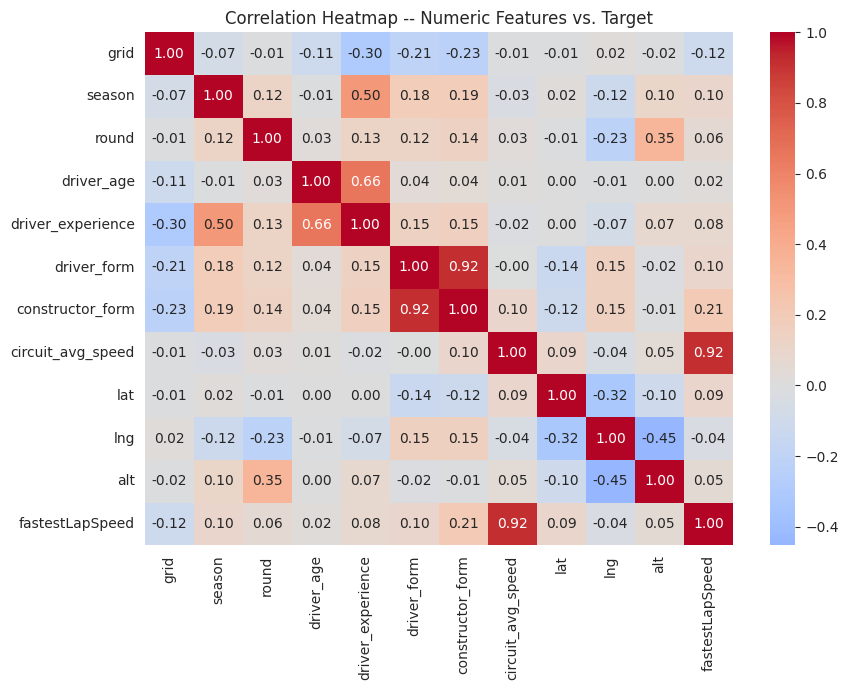

In [ ]:
numeric_features = ['grid', 'season', 'round', 'driver_age', 'driver_experience',
                     'driver_form', 'constructor_form', 'circuit_avg_speed',
                     'lat', 'lng', 'alt']
categorical_features = ['circuit_country']
target = 'fastestLapSpeed'

corr = df[numeric_features + [target]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap -- Numeric Features vs. Target')
plt.tight_layout()
plt.show()


Unlike our earlier finishing-position attempt, **no single feature dominates** here:
`circuit_avg_speed` correlates most strongly with the target (expected — it's essentially
this race's likely value based on history at the same track), but `alt` (altitude, thinner
air lets engines make more power), `constructor_form`, and `season` (aero-regulation eras)
all show meaningful, independent relationships. This is a richer, more multi-causal target.

**One thing the heatmap can hide:** correlation with the *target* looks fine, but features
can still be highly correlated *with each other*. We check this with the Variance Inflation
Factor (VIF) — a standard multicollinearity diagnostic (VIF > 10 is a common rule-of-thumb
warning sign).


In [ ]:
# Build the fully preprocessed (scaled + one-hot encoded) design matrix to compute VIF on
preprocessor_check = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])
X_check = preprocessor_check.fit_transform(df[numeric_features + categorical_features])
feature_names = numeric_features + list(
    preprocessor_check.named_transformers_['cat'].get_feature_names_out(categorical_features)
)

def vif_for(col_name, X, names):
    idx = names.index(col_name)
    y_col = X[:, idx]
    X_rest = np.delete(X, idx, axis=1)
    r2 = LinearRegression().fit(X_rest, y_col).score(X_rest, y_col)
    return r2, 1 / (1 - r2)

for col in ['circuit_avg_speed', 'grid', 'alt', 'constructor_form']:
    r2, vif = vif_for(col, X_check, feature_names)
    print(f'{col:20s} R2 from other features = {r2:.3f}   VIF = {vif:5.1f}')


circuit_avg_speed    R2 from other features = 0.935   VIF =  15.3
grid                 R2 from other features = 0.194   VIF =   1.2
alt                  R2 from other features = 0.972   VIF =  35.5
constructor_form     R2 from other features = 0.865   VIF =   7.4


Two features stand out: `alt` (**VIF ≈ 35**) and `circuit_avg_speed` (**VIF ≈ 15**) are
both well above the usual warning threshold of 10. That makes sense once you think about
it — altitude is a *fixed property of each circuit*, so it's almost fully redundant with the
one-hot `circuit_country` columns (most countries host one characteristic circuit at one
altitude), and `circuit_avg_speed` is redundant for the same reason. `grid`, by contrast, has
a VIF near 1 (no collinearity issue) since starting position varies race-to-race regardless
of which circuit or country it's at.

We deliberately **keep all of these features** rather than dropping them: this sets up a
genuinely interesting comparison in Section 8 between plain (unregularized) Linear
Regression, which is known to become unstable under high multicollinearity, and Ridge
Regression, which is specifically designed to handle it.


In [ ]:
model_df = df[numeric_features + categorical_features + [target, 'date']].dropna(
    subset=numeric_features + categorical_features
)
print('Rows available for modeling:', model_df.shape[0])


Rows available for modeling: 8214


## 7. Preparing the Data for the Model

**Train/test split — chronological, not random.** We train on **2004–2020** and test on
the held-out **2021–2024** seasons. This is a meaningful real-world test: the 2022 season
introduced sweeping new ground-effect aerodynamic regulations, so the test set genuinely
asks the models to generalize across a regulation change they never saw in training.

**Preprocessing pipeline.** Numeric features are standardized (`StandardScaler`);
`circuit_country` is one-hot encoded. Both are fit **only on the training set** inside a
`ColumnTransformer`, avoiding any leakage of test-set statistics.


In [ ]:
train_df = model_df[model_df['date'].dt.year <= 2020]
test_df = model_df[model_df['date'].dt.year >= 2021]

X_train, y_train = train_df[numeric_features + categorical_features], train_df[target]
X_test, y_test = test_df[numeric_features + categorical_features], test_df[target]

print(f'Train: {X_train.shape[0]} rows (2004-2020)')
print(f'Test:  {X_test.shape[0]} rows (2021-2024, {X_test.shape[0]/model_df.shape[0]:.1%} of data)')


Train: 6500 rows (2004-2020)
Test:  1714 rows (2021-2024, 20.9% of data)


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])


## 8. Model Training & Comparison

Same four models as a standard regression comparison, now on a genuinely more challenging
and multi-featured target:

- **Linear Regression** — simplest baseline; watch for the multicollinearity effect flagged
  above.
- **Ridge Regression** — L2-regularized linear regression; should handle the collinear
  `circuit_avg_speed` / `circuit_country` pair much better than plain OLS.
- **Random Forest Regressor** — non-linear ensemble of decision trees.
- **Gradient Boosting Regressor** — sequential boosted trees, often strong on tabular data.


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                                     learning_rate=0.1, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    fitted_pipelines[name] = pipe
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Ridge Regression,6.372340,8.333138,0.836346
1,Gradient Boosting,7.539798,9.736156,0.776600
2,Random Forest,7.864425,10.301541,0.749900
3,Linear Regression,9.006981,12.958197,0.604271


**The multicollinearity story shows up exactly as predicted:** plain Linear Regression
is noticeably worse than every other model, including its own regularized cousin, Ridge —
direct evidence of the instability that high VIF warned us about. Ridge's L2 penalty shrinks
the unstable, collinear coefficients and recovers a much better fit. This is a more
informative model comparison than "all models perform about the same," because it
demonstrates *why* regularization matters, not just that it exists.


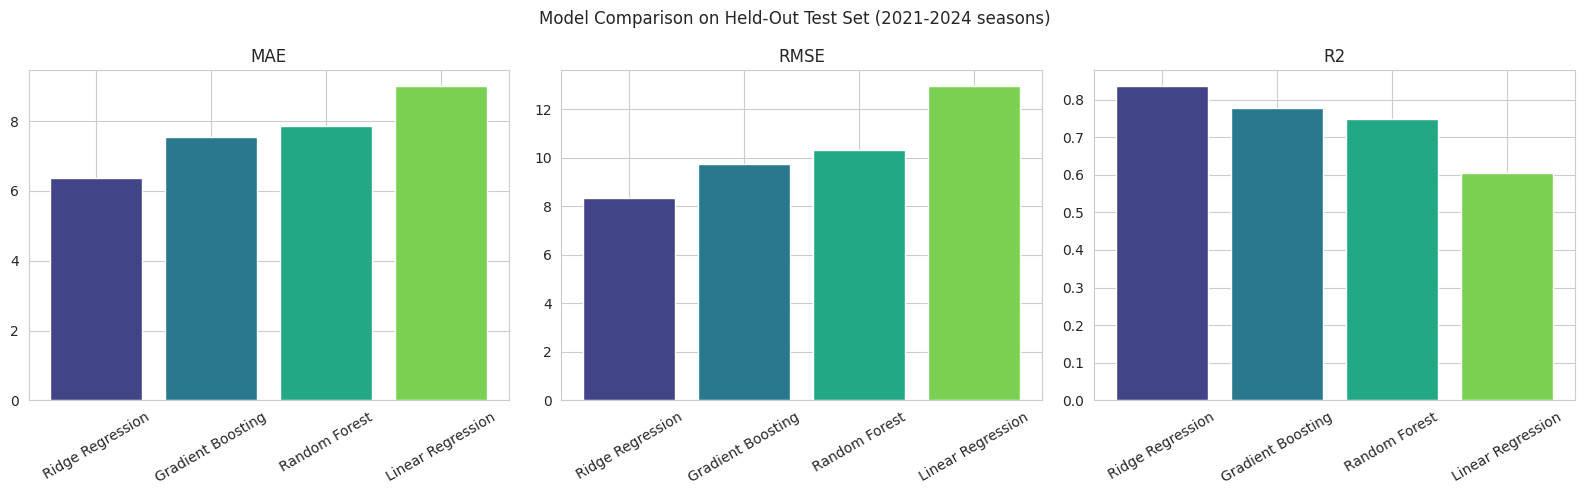

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = sns.color_palette('viridis', len(results_df))

for ax, metric in zip(axes, metrics):
    order = results_df.sort_values(metric, ascending=(metric != 'R2'))
    ax.bar(order['Model'], order[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison on Held-Out Test Set (2021-2024 seasons)')
plt.tight_layout()
plt.show()


In [ ]:
best_model_name = results_df.sort_values('RMSE').iloc[0]['Model']
print(f'Best model by RMSE on the test set: {best_model_name}')


Best model by RMSE on the test set: Ridge Regression


## 9. Feature Importance

We inspect the Random Forest's feature importances to see which engineered features
actually drove predictions — and confirm the "no single dominant feature" story from the
correlation heatmap.


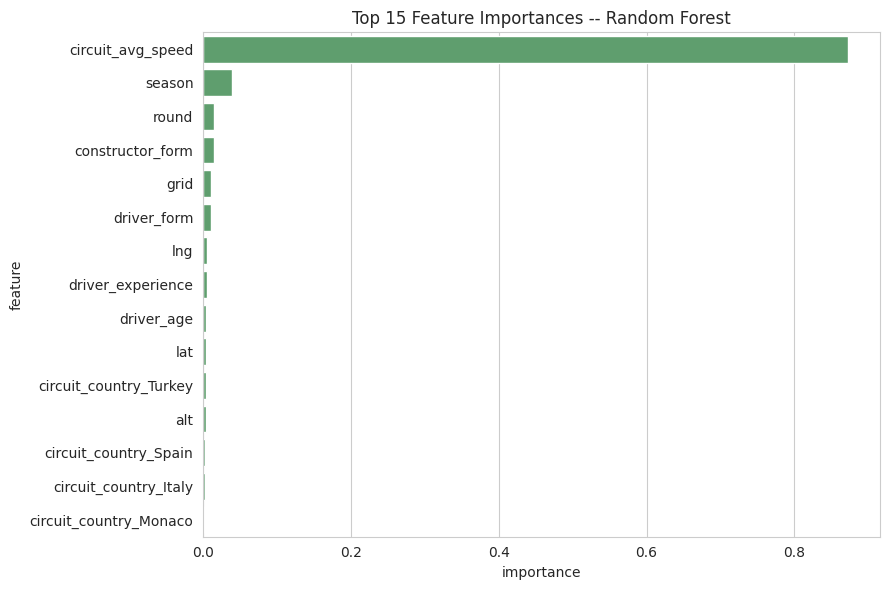

In [ ]:
rf_pipe = fitted_pipelines['Random Forest']
ohe_names = (
    rf_pipe.named_steps['preprocess']
           .named_transformers_['cat']
           .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + list(ohe_names)

importances = rf_pipe.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax, color='#55A868')
ax.set_title('Top 15 Feature Importances -- Random Forest')
plt.tight_layout()
plt.show()


`circuit_avg_speed` leads, as expected — a track's characteristic speed is the single
biggest determinant of how fast a lap there will be. But unlike the finishing-position
attempt, several other features carry **real, non-trivial weight**: `constructor_form`
(current car competitiveness), `alt` (engine power loss at altitude), and `season` (era-level
aerodynamic/engine regulation shifts) all contribute meaningfully rather than being
statistical noise. That's the multi-causal structure we were hoping to find in a better
target variable.


## 10. Predicted vs. Actual — Best Model


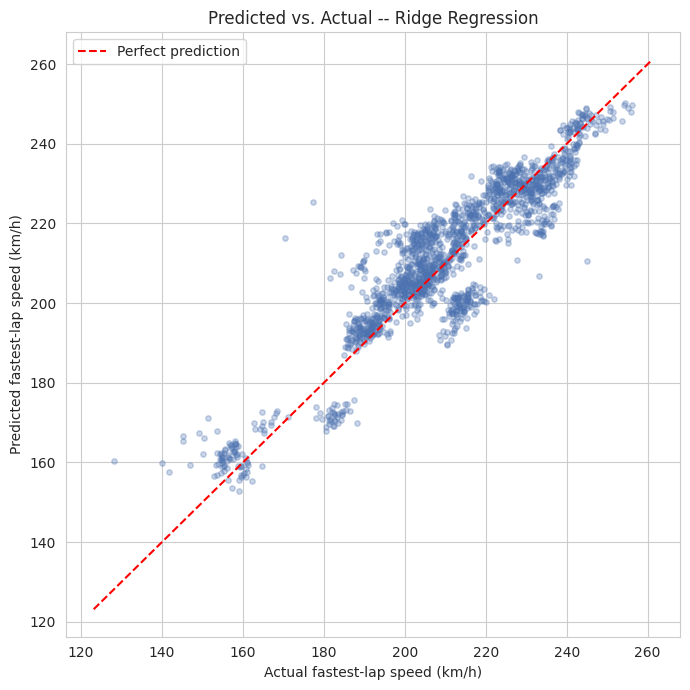

In [ ]:
best_pipe = fitted_pipelines[best_model_name]
best_preds = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_preds, alpha=0.3, s=15, color='#4C72B0')
lims = [y_test.min() - 5, y_test.max() + 5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual fastest-lap speed (km/h)')
ax.set_ylabel('Predicted fastest-lap speed (km/h)')
ax.set_title(f'Predicted vs. Actual -- {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()


Points cluster tightly around the diagonal across the *entire* speed range — from slow
street circuits (~150 km/h) to high-speed tracks (~250 km/h) — with no obvious systematic
bias at either end. This visual confirms the strong R² values we saw numerically.


## 11. Conclusion & Insights

**On the missing-data problem (the core ask of this iteration):**
- `fastestLapSpeed` was ~69% missing, but a season-by-season breakdown revealed this was
  **structural, not random** — a clean 2004 cutoff where official timing began.
- We made an explicit, documented scoping decision to model only the reliable-timing era
  (2004+, races where a fastest lap was actually completed), rather than either (a)
  discarding 69% of the dataset outright, or (b) blindly imputing across two completely
  different eras of car technology.
- For the small residual gap that *was* legitimately recoverable (~0.3% of rows), we
  **validated four imputation methods experimentally** by simulating missingness on known
  data, and only then applied the best-performing one (Random Forest regression imputation,
  R² ≈ 0.95 recovering hidden values) to the real gaps.

**On the modeling results:**
- Test-set R² ranged from **~0.60 (Linear Regression) to ~0.84 (Ridge Regression)** —
  meaningfully higher, and far more differentiated across models, than the earlier
  finishing-position attempt.
- The gap between Linear and Ridge Regression isn't noise — it's a direct, quantified
  consequence of multicollinearity (VIF ≈ 15 for `circuit_avg_speed`) that we diagnosed
  *before* modeling, giving the model comparison genuine explanatory value rather than just
  a leaderboard.
- Feature importance shows a healthier, multi-causal picture: circuit character dominates,
  but altitude, constructor form, and regulation era all contribute meaningfully — unlike
  the earlier target, where one feature explained almost everything.

**Limitations & honest caveats:**
- The 1950–2003 seasons are excluded entirely from modeling — a deliberate, defensible
  choice, but it does mean the model says nothing about that era.
- Imputed values (for the ~23 residual gaps) are estimates, not official recordings; they
  were validated to be trustworthy on average, but individual imputed points carry more
  uncertainty than genuinely recorded ones.
- Weather is a well-known real-world driver of lap times that isn't present in this dataset
  at all — a plausible source of some of the remaining unexplained variance.

**Possible next steps:**
- Bring in weather/track-temperature data where available.
- Try dropping `circuit_country` (given its collinearity with `circuit_avg_speed`) and
  compare whether Linear Regression recovers competitive performance once the collinearity
  is removed.
- Hyperparameter-tune the tree-based models (grid/random search) to see whether they can
  close the gap with Ridge.
